# Importamos el DataSet de wine 

In [1]:
#1. Importamos el DataSet de wine
from sklearn.datasets import load_wine
import pandas as pd

# Cargar el dataset
wine = load_wine()

# Ver descripción completa
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

# Imports

In [2]:
# Instalamos graphviz
!pip install graphviz

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
from pandas import DataFrame

In [4]:
import warnings
# Ignoramos algunos warnings que se producen por invocar el modelo sin el nombre de las características
warnings.filterwarnings('ignore', category=UserWarning, message='.*X does not have valid feature names.*')

# Funciones auxiliares

In [5]:
# Construcción de una función que realice el particionado completo
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

In [6]:
def remove_labels(df, label_name): #Separa las características de entrada de las de salida
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [7]:
# Muestra información de la evaluación del conjunto transformado y el conjunto original
def evaluate_result(y_pred, y, y_prep_pred, y_prep, metric):
    print(metric.__name__, "WITHOUT preparation:", metric(y_pred, y, average='weighted'))
    print(metric.__name__, "WITH preparation:", metric(y_prep_pred, y_prep, average='weighted'))

# 1. Visualización del conjunto de datos

NOTA: Hemos importado arriba el DataSet, en este ejercicio no tenemos un .csv

In [8]:
# Convertir a DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Primeras filas
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [10]:
df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

### Buscando correlaciones

In [11]:
# Copiamos el conjunto de datos y transformamos la variable de salida a numérica para calcular correlaciones
X = df.copy()
X['target'] = X['target'].factorize()[0]

In [12]:
# Calculamos correlaciones
corr_matrix = X.corr()
corr_matrix["target"].sort_values(ascending=False)

target                          1.000000
alcalinity_of_ash               0.517859
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
color_intensity                 0.265668
ash                            -0.049643
magnesium                      -0.209179
alcohol                        -0.328222
proanthocyanins                -0.499130
hue                            -0.617369
proline                        -0.633717
total_phenols                  -0.719163
od280/od315_of_diluted_wines   -0.788230
flavanoids                     -0.847498
Name: target, dtype: float64

In [13]:
X.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


In [14]:
# Se puede llegar a valorar quedarnos con aquellas que tienen mayor correlación
corr_matrix[corr_matrix["target"] > 0.05]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668
target,-0.328222,0.437776,-0.049643,0.517859,-0.209179,-0.719163,-0.847498,0.489109,-0.499130,0.265668,-0.617369,-0.788230,-0.633717,1.000000


# 2. División del conjunto de datos

In [15]:
# Dividimos el conjunto de datos
train_set, val_set, test_set = train_val_test_split(X)

In [16]:
X_train, y_train = remove_labels(train_set, 'target')
X_val, y_val = remove_labels(val_set, 'target')
X_test, y_test = remove_labels(test_set, 'target')

# 3. Escalando el conjunto de datos

In [17]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [18]:
X_test_scaled = scaler.transform(X_test)

In [19]:
X_val_scaled = scaler.transform(X_val)

In [20]:
# Transformación a un DataFrame de Pandas
X_train_scaled = DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_train_scaled.head(10)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
75,-0.908127,-0.052718,-1.600000,-0.987654,-0.101266,-0.544681,-0.292398,0.000000,-0.600760,-0.343699,0.866142,-0.477231,-0.489400
10,0.816254,0.131796,-0.278261,-0.493827,0.303797,0.595745,0.730994,-0.578313,1.269962,0.294599,0.929134,0.273224,2.132041
147,-0.053004,1.746293,0.347826,0.370370,-0.658228,-0.468085,-0.830409,0.626506,-1.041825,0.916530,-1.307087,-0.681239,-0.012114
123,0.074205,2.530478,-0.869565,0.370370,-0.658228,0.314894,0.339181,-0.192771,0.707224,-0.736498,-0.708661,0.222222,-0.605694
0,0.908127,-0.164745,0.173913,-1.086420,1.417722,0.468085,0.578947,-0.289157,1.133080,0.258592,0.267717,0.819672,1.053907
142,0.406360,0.797364,1.182609,0.864198,-0.101266,-0.595745,-0.906433,0.771084,-1.513308,-0.163666,-0.204724,-0.535519,-0.266505
126,-0.363958,-0.283361,-0.313043,0.370370,-0.658228,0.417021,0.631579,0.240964,0.342205,-0.297872,-0.834646,0.032787,-0.673531
64,-0.547703,-0.336079,0.521739,-0.246914,0.253165,-0.306383,-0.187135,0.530120,-0.783270,-0.621931,1.559055,-0.411658,-0.666263
44,0.074205,-0.125206,-0.973913,-0.740741,0.405063,0.638298,0.543860,-0.289157,0.737643,0.062193,-0.236220,0.404372,0.617807
96,-0.802120,0.105437,1.252174,0.370370,1.772152,-0.553191,-0.631579,-0.963855,0.022814,-0.769231,-0.015748,-0.389800,-0.012114


In [21]:
X_train_scaled.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,1.060000e+02,1.060000e+02,106.000000,106.000000,106.000000
mean,0.005467,0.302384,0.017063,-0.051945,0.060186,0.045765,-0.018813,0.142305,5.509721e-02,6.333570e-02,-0.008736,-0.150737,0.235558
std,0.608313,0.729984,0.931786,0.891269,0.688916,0.568328,0.602077,0.631460,8.554680e-01,7.253520e-01,0.744471,0.536621,0.740136
min,-1.353357,-0.705107,-3.547826,-2.320988,-1.468354,-0.978723,-0.935673,-1.012048,-1.711027e+00,-1.018003e+00,-1.496063,-1.111111,-0.852816
25%,-0.462898,-0.202636,-0.443478,-0.530864,-0.556962,-0.468085,-0.505848,-0.373494,-4.486692e-01,-5.335516e-01,-0.551181,-0.710383,-0.327075
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.682682e-16,1.457168e-16,0.000000,0.000000,0.000000
75%,0.537102,0.797364,0.556522,0.469136,0.443038,0.531915,0.494152,0.626506,5.513308e-01,4.664484e-01,0.448819,0.289617,0.672925
max,1.332155,2.530478,2.956522,2.469136,2.025316,1.387234,1.760234,1.542169,3.095057e+00,1.947627e+00,2.377953,0.819672,2.221684


# 4. Arbol de decisión

In [22]:
from sklearn.tree import DecisionTreeClassifier

MAX_DEPTH = 20

# Modelo entrenado con el conjunto de datos sin escalar
clf_tree = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=42)
clf_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
# Modelo entrenado con el conjunto de datos escalado
clf_tree_scaled = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=42)
clf_tree_scaled.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
# Predecimos con el conjunto de datos de entrenamiento
y_train_pred = clf_tree.predict(X_train)
y_train_prep_pred = clf_tree_scaled.predict(X_train_scaled)

In [25]:
# Comparamos resultados entre escalado y sin escalar
evaluate_result(y_train_pred, y_train, y_train_prep_pred, y_train, f1_score)

f1_score WITHOUT preparation: 1.0
f1_score WITH preparation: 1.0


In [26]:
# Predecimos con el conjunto de datos de validación
y_pred = clf_tree.predict(X_val)
y_prep_pred = clf_tree_scaled.predict(X_val_scaled)

In [27]:
# Comparamos resultados entre escalado y sin escalar
evaluate_result(y_pred, y_val, y_prep_pred, y_val, f1_score)

f1_score WITHOUT preparation: 0.9722705314009663
f1_score WITH preparation: 0.9722705314009663


# 5. Visualizando el límite de decisión

In [28]:
# Reducimos el número de atributos del conjunto de datos para visualizarlo mejor
X_train_reduced = X_train[['alcohol', 'malic_acid']]

In [29]:
# Generamos un modelo con el conjunto de datos reducido
clf_tree_reduced = DecisionTreeClassifier(max_depth=20, random_state=42)
clf_tree_reduced.fit(X_train_reduced, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


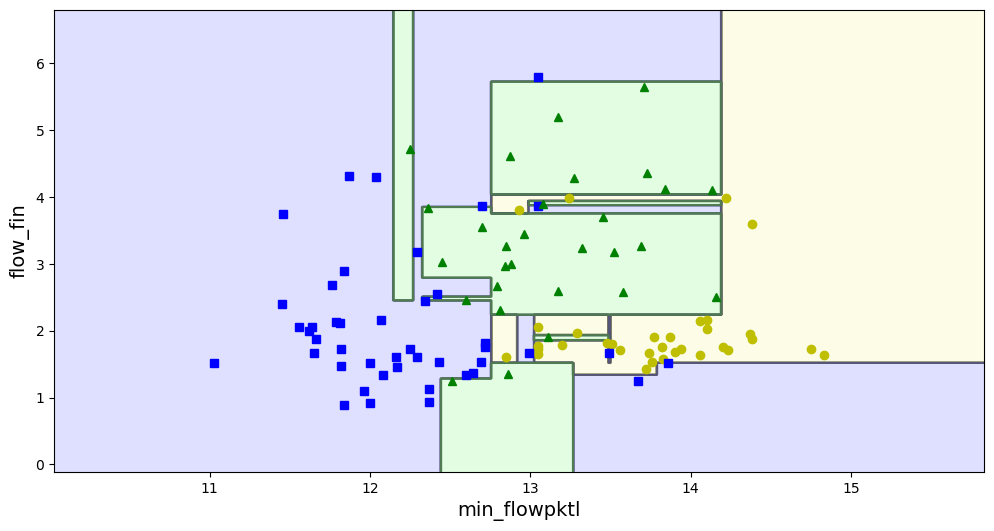

In [30]:
# Representamos gráficamente el límite de decisión construido
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
%matplotlib inline

def plot_decision_boundary(clf, X, y, plot_training=True, resolution=1000):
    mins = X.min(axis=0) - 1
    maxs = X.max(axis=0) + 1
    x1, x2 = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
    plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="normal")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="adware")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="malware")
        plt.axis([mins[0], maxs[0], mins[1], maxs[1]])               
    plt.xlabel('min_flowpktl', fontsize=14)
    plt.ylabel('flow_fin', fontsize=14, rotation=90)

plt.figure(figsize=(12, 6))
plot_decision_boundary(clf_tree_reduced, X_train_reduced.values, y_train)
plt.show()

# Cada clase está pintada de un color, amarillo las normales, azul adware y verde malware... pinta con líneas en verde los límites de decisión que establece

In [ ]:
# Pintamos el árbol para compararlo con la representación gráfica anterior
from graphviz import Source
from sklearn.tree import export_graphviz
import os

export_graphviz(
        clf_tree_reduced,
        out_file="wine_output.dot",
        feature_names=X_train_reduced.columns,
        class_names=["class_0", "class_1", "class_2"],
        rounded=True,
        filled=True
    )
Source.from_file("wine_output.dot")